# Model Comparison — All Methods

Loads saved model files from `../Models/` and evaluates every method on the **same held-out test set**.
No training happens here — just inference and metrics.

| Task | Dataset | Split |
|---|---|---|
| Linear Regression | California Housing | `train_test_split(test_size=0.2, random_state=42)` |
| Logistic Regression | NLTK Twitter Samples | `random.seed(42)` shuffle → 80/20 |
| Naive Bayes | NLTK Twitter Samples | `random.seed(42)` shuffle → 80/20 |
| K-Means Clustering | `make_blobs` (4 centers, 1500 pts) | Unsupervised — full dataset |
| Decision Tree | Iris (4 features, 3 classes) | `train_test_split(test_size=0.2, random_state=42, stratify=y)` |
| K-Nearest Neighbours | Iris (4 features, 3 classes) | `train_test_split(test_size=0.2, random_state=42, stratify=y)` |

> **Run order:** individual notebooks (any order) → `model_comparison.ipynb` last.
> **Prerequisites:** run each individual notebook first so the `../Models/` files exist.

In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import json, re, os, math, random
import joblib
from collections import Counter

required = [
    # Linear Regression
    'Models/lr_scratch.json',         'Models/lr_numpy.npz',         'Models/lr_sklearn.joblib',
    'Models/ridge_numpy.npz',          'Models/lasso_numpy.npz',
    'Models/ridge_sklearn.joblib',     'Models/lasso_sklearn.joblib',
    # Tweet Classification
    'Models/logreg_scratch.json',      'Models/logreg_numpy.npz',     'Models/logreg_sklearn.joblib',
    'Models/naive_bayes_scratch.json', 'Models/naive_bayes_numpy.npz','Models/naive_bayes_sklearn.joblib',
    # Clustering
    'Models/kmeans_scratch.json',      'Models/kmeans_numpy.npz',     'Models/kmeans_sklearn.joblib',
    # Iris Classification
    'Models/dt_scratch.json',          'Models/dt_numpy.json',        'Models/dt_sklearn.joblib',
    'Models/knn_scratch.json',         'Models/knn_numpy.npz',        'Models/knn_sklearn.joblib',
    # Breast Cancer Classification
    'Models/svm_scratch.npz',          'Models/svm_numpy.npz',        'Models/svm_sklearn.joblib',
    'Models/nn_scratch.npz',           'Models/nn_numpy.npz',
    'Models/nn_pytorch_weights.pth',   'Models/nn_pytorch_config.json',
]
missing = [p for p in required if not os.path.exists(p)]
if missing:
    print('Missing model files (run individual notebooks first):')
    for p in missing: print(f'  {p}')
else:
    print(f'All {len(required)} model files found ✓')

All 29 model files found ✓


---
# Part 1 — Linear Regression

Reconstruct the test set, load each saved model, predict, and compute metrics.

In [16]:
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split

raw  = fetch_california_housing(as_frame=True)
X_df = raw.frame[raw.feature_names]
y_s  = raw.frame['MedHouseVal']

# Same split used when training all LR models
_, X_te_df, _, y_te = train_test_split(X_df, y_s, test_size=0.2, random_state=42)
X_te_np = X_te_df.values
y_te_np = y_te.values

print(f"Test set: {len(X_te_df):,} rows  |  Features: {X_te_df.shape[1]}")

Test set: 4,128 rows  |  Features: 8


In [17]:
def regression_metrics(y_true, y_pred):
    resid  = y_true - y_pred
    mse    = np.mean(resid ** 2)
    rmse   = np.sqrt(mse)
    r2     = 1 - np.sum(resid**2) / np.sum((y_true - np.mean(y_true))**2)
    return dict(MSE=round(mse,4), RMSE=round(rmse,4), R2=round(r2,4))

lr_results = []

### Method 1 & 2 — OLS + GD (Pandas Scratch)

In [18]:
with open('Models/lr_scratch.json') as f:
    lr_sc = json.load(f)

feat = lr_sc['feature_names']

# ── OLS: add bias, dot with saved coefficients ──
ols_coef = lr_sc['ols']['coefficients']           # dict  {feature: coef}
X_te_bias = X_te_df.copy().reset_index(drop=True)
X_te_bias.insert(0, 'bias', 1.0)
beta_ols_pd = pd.Series(ols_coef)
y_pred_ols  = X_te_bias.dot(beta_ols_pd).values

m = regression_metrics(y_te_np, y_pred_ols)
lr_results.append({'Method': 'OLS — Pandas', **m})
print(f"OLS Pandas | {m}")

# ── GD: min-max scale, add bias, dot with saved coefficients ──
gd_coef = lr_sc['gd']['coefficients']
x_min   = pd.Series(lr_sc['gd']['x_min'])
x_max   = pd.Series(lr_sc['gd']['x_max'])

X_te_sc = X_te_df.copy().reset_index(drop=True)
X_te_sc = (X_te_sc - x_min) / (x_max - x_min)
X_te_sc.insert(0, 'bias', 1.0)
beta_gd_pd  = pd.Series(gd_coef)
y_pred_gd   = X_te_sc.dot(beta_gd_pd).values

m = regression_metrics(y_te_np, y_pred_gd)
lr_results.append({'Method': 'GD — Pandas', **m})
print(f"GD  Pandas | {m}")

OLS Pandas | {'MSE': np.float64(0.5439), 'RMSE': np.float64(0.7375), 'R2': np.float64(0.585)}
GD  Pandas | {'MSE': np.float64(0.5884), 'RMSE': np.float64(0.7671), 'R2': np.float64(0.551)}


### Method 3 & 4 — OLS + GD (NumPy)

In [19]:
lr_np = np.load('Models/lr_numpy.npz', allow_pickle=True)

# ── OLS ──
beta_ols_np = lr_np['beta_ols']
X_te_b      = np.column_stack([np.ones(len(X_te_np)), X_te_np])
y_pred_ols_np = X_te_b @ beta_ols_np

m = regression_metrics(y_te_np, y_pred_ols_np)
lr_results.append({'Method': 'OLS — NumPy', **m})
print(f"OLS NumPy  | {m}")

# ── GD (z-score scaled) ──
beta_gd_np = lr_np['beta_gd']
x_mean     = lr_np['x_mean']
x_std      = lr_np['x_std']

X_te_scb = np.column_stack([np.ones(len(X_te_np)), (X_te_np - x_mean) / x_std])
y_pred_gd_np = X_te_scb @ beta_gd_np

m = regression_metrics(y_te_np, y_pred_gd_np)
lr_results.append({'Method': 'GD — NumPy', **m})
print(f"GD  NumPy  | {m}")

OLS NumPy  | {'MSE': np.float64(0.5559), 'RMSE': np.float64(0.7456), 'R2': np.float64(0.5758)}
GD  NumPy  | {'MSE': np.float64(0.5559), 'RMSE': np.float64(0.7456), 'R2': np.float64(0.5758)}


### Method 5 — sklearn

In [20]:
lr_sk     = joblib.load('Models/lr_sklearn.joblib')
y_pred_sk = lr_sk.predict(X_te_df)

m = regression_metrics(y_te_np, y_pred_sk)
lr_results.append({'Method': 'sklearn', **m})
print(f"sklearn    | {m}")

sklearn    | {'MSE': np.float64(0.5559), 'RMSE': np.float64(0.7456), 'R2': np.float64(0.5758)}


## Linear Regression — Results Table

### Method 6 & 7 — Ridge + Lasso (NumPy)

In [21]:
ridge_np  = np.load('Models/ridge_numpy.npz', allow_pickle=True)
lasso_np  = np.load('Models/lasso_numpy.npz', allow_pickle=True)

def _predict_reg_np(data, X_te):
    beta   = data['beta']
    x_mean = data['x_mean']; x_std = data['x_std']; y_mean = float(data['y_mean'])
    X_sc   = (X_te - x_mean) / x_std
    return X_sc @ beta + y_mean

y_pred_ridge_np = _predict_reg_np(ridge_np, X_te_np)
y_pred_lasso_np = _predict_reg_np(lasso_np, X_te_np)

m = regression_metrics(y_te_np, y_pred_ridge_np)
lr_results.append({'Method': f'Ridge NumPy (α={float(ridge_np["alpha"]):.3f})', **m})
print(f"Ridge NumPy  | {m}")

m = regression_metrics(y_te_np, y_pred_lasso_np)
lr_results.append({'Method': f'Lasso NumPy (α={float(lasso_np["alpha"]):.4f})', **m})
print(f"Lasso NumPy  | {m}")

Ridge NumPy  | {'MSE': np.float64(0.5559), 'RMSE': np.float64(0.7456), 'R2': np.float64(0.5758)}
Lasso NumPy  | {'MSE': np.float64(0.5545), 'RMSE': np.float64(0.7446), 'R2': np.float64(0.5769)}


### Method 8 & 9 — Ridge + Lasso (sklearn)

In [22]:
ridge_sk  = joblib.load('Models/ridge_sklearn.joblib')
lasso_sk  = joblib.load('Models/lasso_sklearn.joblib')

ridge_alpha = ridge_sk['model'].alpha_
lasso_alpha = lasso_sk['model'].alpha_

y_pred_ridge_sk = ridge_sk.predict(X_te_df)
y_pred_lasso_sk = lasso_sk.predict(X_te_df)

m = regression_metrics(y_te_np, y_pred_ridge_sk)
lr_results.append({'Method': f'Ridge sklearn (α={ridge_alpha:.3f})', **m})
print(f"Ridge sklearn | {m}")

m = regression_metrics(y_te_np, y_pred_lasso_sk)
lr_results.append({'Method': f'Lasso sklearn (α={lasso_alpha:.5f})', **m})
print(f"Lasso sklearn | {m}")

Ridge sklearn | {'MSE': np.float64(0.5559), 'RMSE': np.float64(0.7456), 'R2': np.float64(0.5758)}
Lasso sklearn | {'MSE': np.float64(0.555), 'RMSE': np.float64(0.745), 'R2': np.float64(0.5765)}


In [23]:
lr_df = pd.DataFrame(lr_results).set_index('Method')

lr_df.style \
    .highlight_min(subset=['MSE','RMSE'], color='#c6efce') \
    .highlight_max(subset=['R2'],         color='#c6efce') \
    .format({'MSE':'{:.4f}','RMSE':'{:.4f}','R2':'{:.4f}'})

,MSE,RMSE,R2
Method,,,
OLS — Pandas,0.5439,0.7375,0.5850
GD — Pandas,0.5884,0.7671,0.5510
OLS — NumPy,0.5559,0.7456,0.5758
GD — NumPy,0.5559,0.7456,0.5758
sklearn,0.5559,0.7456,0.5758
Ridge NumPy (α=0.154),0.5559,0.7456,0.5758
Lasso NumPy (α=0.0010),0.5545,0.7446,0.5769
Ridge sklearn (α=0.001),0.5559,0.7456,0.5758
Lasso sklearn (α=0.00064),0.5550,0.7450,0.5765


## Linear Regression — Performance Charts

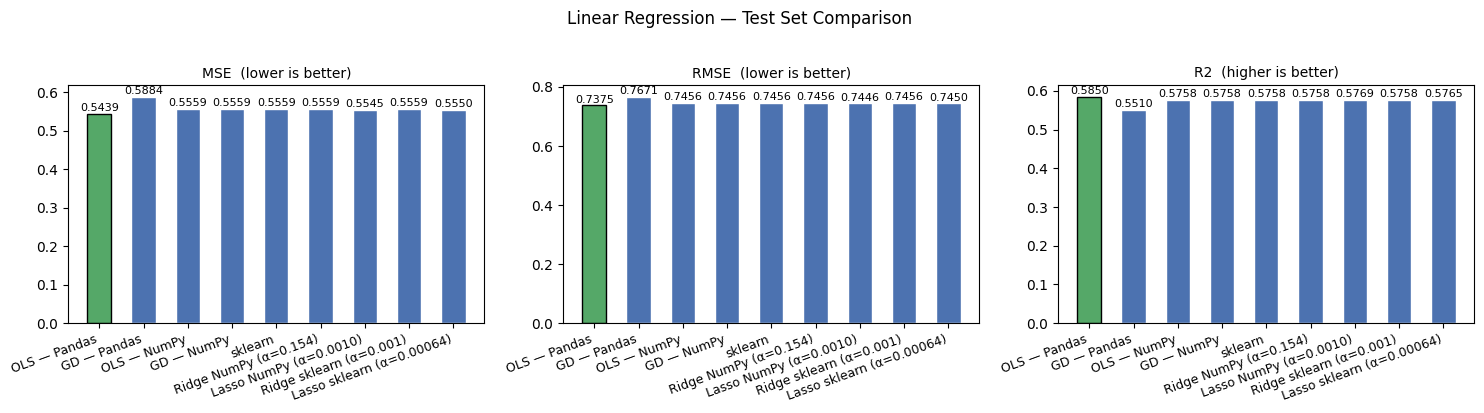

In [24]:
methods = lr_df.index.tolist()
x       = np.arange(len(methods))

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col, better in zip(axes, ['MSE','RMSE','R2'], ['lower','lower','higher']):
    vals = lr_df[col].values
    bars = ax.bar(x, vals, color='#4C72B0', edgecolor='white', width=0.55)
    best = np.argmin(vals) if better == 'lower' else np.argmax(vals)
    bars[best].set_color('#55A868'); bars[best].set_edgecolor('black')
    ax.set_xticks(x)
    ax.set_xticklabels(methods, rotation=20, ha='right', fontsize=9)
    ax.set_title(f'{col}  ({better} is better)', fontsize=10)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.002,
                f'{val:.4f}', ha='center', va='bottom', fontsize=8)

plt.suptitle('Linear Regression — Test Set Comparison', fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

---
# Part 2 — Logistic Regression + Naive Bayes

Reconstruct the tweet test set (same shuffle seed), load each model, predict.

In [25]:
import nltk
nltk.download('twitter_samples', quiet=True)
nltk.download('stopwords',       quiet=True)
from nltk.corpus import twitter_samples, stopwords as nltk_sw

STOPWORDS = set(nltk_sw.words('english'))

def clean(text):
    text = text.lower()
    text = re.sub(r'http\S+|www\S+', '', text)
    text = re.sub(r'@\w+', '', text)
    text = re.sub(r'#', '', text)
    text = re.sub(r'[^a-z\s]', '', text)
    return [t for t in text.split() if t not in STOPWORDS and len(t) > 1]

def clean_str(text):       # string version for sklearn
    return ' '.join(clean(text))

pos = twitter_samples.strings('positive_tweets.json')
neg = twitter_samples.strings('negative_tweets.json')
all_tokens = [clean(t) for t in pos + neg]
all_labels = [1]*len(pos) + [0]*len(neg)

combined = list(zip(all_tokens, all_labels))
random.seed(42)
random.shuffle(combined)
all_tokens, all_labels = zip(*combined)
all_tokens, all_labels = list(all_tokens), list(all_labels)

split = int(len(all_tokens) * 0.8)
test_tokens = all_tokens[split:]
y_te_log    = np.array(all_labels[split:])

# Plain string versions for sklearn models
test_strings = [' '.join(t) for t in test_tokens]

print(f"Test tweets: {len(test_tokens):,}  |  Pos: {y_te_log.sum():,}  Neg: {(y_te_log==0).sum():,}")

Test tweets: 2,000  |  Pos: 1,006  Neg: 994


In [26]:
def clf_metrics(y_true, y_pred, y_prob=None):
    from sklearn.metrics import roc_auc_score
    tp = np.sum((y_pred==1)&(y_true==1)); tn = np.sum((y_pred==0)&(y_true==0))
    fp = np.sum((y_pred==1)&(y_true==0)); fn = np.sum((y_pred==0)&(y_true==1))
    acc  = (tp+tn)/len(y_true)
    prec = tp/(tp+fp) if (tp+fp)>0 else 0
    rec  = tp/(tp+fn) if (tp+fn)>0 else 0
    f1   = 2*prec*rec/(prec+rec) if (prec+rec)>0 else 0
    auc  = round(roc_auc_score(y_true, y_prob), 4) if y_prob is not None else None
    result = dict(Accuracy=round(acc,4), Precision=round(prec,4),
                  Recall=round(rec,4), F1=round(f1,4))
    if auc: result['ROC-AUC'] = auc
    return result

def sigmoid(z):
    return 1.0 / (1.0 + np.exp(-np.clip(z, -500, 500)))

# TF-IDF helpers (needed for scratch and numpy logreg inference)
def tfidf_transform_np(token_lists, vocab, word2idx, idf):
    V = len(vocab)
    X = np.zeros((len(token_lists), V), dtype=np.float32)
    for i, doc in enumerate(token_lists):
        if not doc: continue
        cnt = Counter(doc)
        for w, c in cnt.items():
            if w in word2idx:
                X[i, word2idx[w]] = (c / len(doc)) * idf[word2idx[w]]
        norm = np.linalg.norm(X[i])
        if norm > 0: X[i] /= norm
    return X

clf_results = []

### LogReg Method 1 — GD (Pandas Scratch)

In [27]:
with open('Models/logreg_scratch.json') as f:
    lg_sc = json.load(f)

vocab_sc    = lg_sc['vocab']
word2idx_sc = {w: i for i, w in enumerate(vocab_sc)}
idf_sc      = np.array([lg_sc['idf'].get(w, 1.0) for w in vocab_sc])
beta_sc     = pd.Series(lg_sc['beta'])

X_te_sc = tfidf_transform_np(test_tokens, vocab_sc, word2idx_sc, idf_sc)
X_te_sc_b = np.column_stack([np.ones(len(X_te_sc)), X_te_sc])
X_te_sc_pd = pd.DataFrame(X_te_sc_b, columns=['bias'] + vocab_sc)

prob_sc    = sigmoid(X_te_sc_pd.dot(beta_sc).values)
y_pred_sc  = (prob_sc >= 0.5).astype(int)

m = clf_metrics(y_te_log, y_pred_sc, prob_sc)
clf_results.append({'Model': 'LogReg', 'Method': 'GD — Pandas', **m})
print(f"LogReg GD Pandas | {m}")

LogReg GD Pandas | {'Accuracy': np.float64(0.7565), 'Precision': np.float64(0.8021), 'Recall': np.float64(0.6849), 'F1': np.float64(0.7389), 'ROC-AUC': 0.833}


### LogReg Method 2 — GD (NumPy)

In [28]:
lg_np    = np.load('Models/logreg_numpy.npz', allow_pickle=True)
vocab_np = lg_np['vocab'].tolist()
w2i_np   = {w: i for i, w in enumerate(vocab_np)}
idf_np   = lg_np['idf']
beta_np  = lg_np['beta']

X_te_np_tfidf = tfidf_transform_np(test_tokens, vocab_np, w2i_np, idf_np)
X_te_np_b     = np.column_stack([np.ones(len(X_te_np_tfidf)), X_te_np_tfidf])

prob_np_lg   = sigmoid(X_te_np_b @ beta_np)
y_pred_np_lg = (prob_np_lg >= 0.5).astype(int)

m = clf_metrics(y_te_log, y_pred_np_lg, prob_np_lg)
clf_results.append({'Model': 'LogReg', 'Method': 'GD — NumPy', **m})
print(f"LogReg GD NumPy  | {m}")

LogReg GD NumPy  | {'Accuracy': np.float64(0.718), 'Precision': np.float64(0.7805), 'Recall': np.float64(0.6113), 'F1': np.float64(0.6856), 'ROC-AUC': 0.8041}


### LogReg Method 3 — sklearn

In [29]:
lg_sk_obj   = joblib.load('Models/logreg_sklearn.joblib')
vec_sk      = lg_sk_obj['vectorizer']
model_sk    = lg_sk_obj['model']

X_te_sk     = vec_sk.transform(test_strings)
prob_sk_lg  = model_sk.predict_proba(X_te_sk)[:, 1]
y_pred_sk_lg = model_sk.predict(X_te_sk)

m = clf_metrics(y_te_log, y_pred_sk_lg, prob_sk_lg)
clf_results.append({'Model': 'LogReg', 'Method': 'sklearn', **m})
print(f"LogReg sklearn   | {m}")

LogReg sklearn   | {'Accuracy': np.float64(0.837), 'Precision': np.float64(0.8594), 'Recall': np.float64(0.8082), 'F1': np.float64(0.833), 'ROC-AUC': 0.9148}


### NB Method 1 — Multinomial NB (Scratch)

In [30]:
with open('Models/naive_bayes_scratch.json') as f:
    nb_sc = json.load(f)

vocab_nb_sc    = nb_sc['vocab']
log_prior_sc   = {int(k): v for k, v in nb_sc['log_prior'].items()}
log_like_sc    = {int(k): v for k, v in nb_sc['log_likelihood'].items()}

def predict_nb_scratch(token_lists, log_prior, log_like):
    preds, probs = [], []
    for tokens in token_lists:
        scores = {}
        for c in [0, 1]:
            s = log_prior[c]
            for w in tokens:
                s += log_like[c].get(w, log_like[c]['<OOV>'])
            scores[c] = s
        label = max(scores, key=scores.get)
        max_s = max(scores[0], scores[1])
        e0, e1 = math.exp(scores[0]-max_s), math.exp(scores[1]-max_s)
        preds.append(label)
        probs.append(e1 / (e0 + e1))
    return np.array(preds), np.array(probs)

y_pred_nb_sc, prob_nb_sc = predict_nb_scratch(test_tokens, log_prior_sc, log_like_sc)
m = clf_metrics(y_te_log, y_pred_nb_sc, prob_nb_sc)
clf_results.append({'Model': 'Naive Bayes', 'Method': 'Scratch', **m})
print(f"NB Scratch | {m}")

NB Scratch | {'Accuracy': np.float64(0.8265), 'Precision': np.float64(0.8443), 'Recall': np.float64(0.8032), 'F1': np.float64(0.8232), 'ROC-AUC': 0.9109}


### NB Method 2 — Multinomial NB (NumPy)

In [31]:
nb_np        = np.load('Models/naive_bayes_numpy.npz', allow_pickle=True)
vocab_nb_np  = nb_np['vocab'].tolist()
w2i_nb_np    = {w: i for i, w in enumerate(vocab_nb_np)}
lp_nb_np     = nb_np['log_prior']       # (2,)
ll_nb_np     = nb_np['log_likelihood']  # (2, V)
V_nb         = len(vocab_nb_np)

def bow_matrix(token_lists, word2idx, V):
    X = np.zeros((len(token_lists), V), dtype=np.int32)
    for i, doc in enumerate(token_lists):
        for w in doc:
            if w in word2idx:
                X[i, word2idx[w]] += 1
    return X

X_te_bow  = bow_matrix(test_tokens, w2i_nb_np, V_nb)
log_post  = lp_nb_np + X_te_bow @ ll_nb_np.T       # (n, 2)
log_post -= log_post.max(axis=1, keepdims=True)    # stable softmax
exp_lp    = np.exp(log_post)
prob_nb_np  = (exp_lp / exp_lp.sum(axis=1, keepdims=True))[:, 1]
y_pred_nb_np = np.argmax(log_post, axis=1)

m = clf_metrics(y_te_log, y_pred_nb_np, prob_nb_np)
clf_results.append({'Model': 'Naive Bayes', 'Method': 'NumPy', **m})
print(f"NB NumPy   | {m}")

NB NumPy   | {'Accuracy': np.float64(0.7455), 'Precision': np.float64(0.7758), 'Recall': np.float64(0.6948), 'F1': np.float64(0.7331), 'ROC-AUC': 0.8254}


### NB Method 3 — sklearn MultinomialNB

In [32]:
nb_sk_pipeline = joblib.load('Models/naive_bayes_sklearn.joblib')

prob_nb_sk   = nb_sk_pipeline.predict_proba(test_strings)[:, 1]
y_pred_nb_sk = nb_sk_pipeline.predict(test_strings)

m = clf_metrics(y_te_log, y_pred_nb_sk, prob_nb_sk)
clf_results.append({'Model': 'Naive Bayes', 'Method': 'sklearn', **m})
print(f"NB sklearn | {m}")

NB sklearn | {'Accuracy': np.float64(0.834), 'Precision': np.float64(0.8695), 'Recall': np.float64(0.7883), 'F1': np.float64(0.8269), 'ROC-AUC': 0.9181}


---
## Classification Results — Full Table

In [33]:
clf_df = pd.DataFrame(clf_results).set_index(['Model', 'Method'])

clf_df.style \
    .highlight_max(subset=['Accuracy','Precision','Recall','F1','ROC-AUC'], color='#c6efce') \
    .format({c: '{:.4f}' for c in clf_df.columns})

## Classification — Side-by-Side Charts

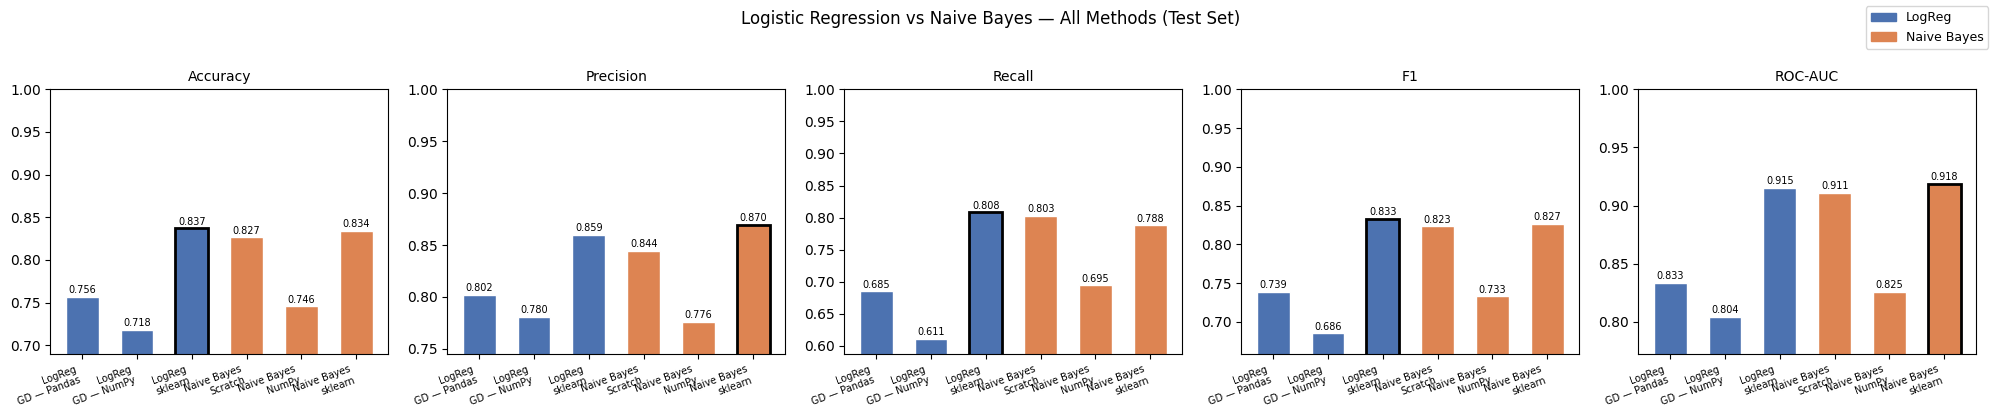

In [34]:
metrics_to_plot = ['Accuracy', 'Precision', 'Recall', 'F1', 'ROC-AUC']
clf_flat        = pd.DataFrame(clf_results)
clf_flat['Label'] = clf_flat['Model'] + '\n' + clf_flat['Method']
labels   = clf_flat['Label'].tolist()
x        = np.arange(len(labels))

# Color by model type
palette = {'LogReg': '#4C72B0', 'Naive Bayes': '#DD8452'}
colors  = [palette[m] for m in clf_flat['Model']]

fig, axes = plt.subplots(1, len(metrics_to_plot), figsize=(20, 4))
for ax, metric in zip(axes, metrics_to_plot):
    vals = clf_flat[metric].values
    bars = ax.bar(x, vals, color=colors, edgecolor='white', width=0.6)
    bars[np.argmax(vals)].set_edgecolor('black')
    bars[np.argmax(vals)].set_linewidth(2)
    ax.set_xticks(x)
    ax.set_xticklabels(labels, fontsize=7, rotation=20, ha='right')
    ax.set_ylim(min(vals)*0.96, 1.0)
    ax.set_title(metric, fontsize=10)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.002,
                f'{val:.3f}', ha='center', va='bottom', fontsize=7)

# Legend
from matplotlib.patches import Patch
legend_els = [Patch(color=c, label=k) for k, c in palette.items()]
fig.legend(handles=legend_els, loc='upper right', fontsize=9)
plt.suptitle('Logistic Regression vs Naive Bayes — All Methods (Test Set)', fontsize=12, y=1.03)
plt.tight_layout()
plt.show()

---
## ROC Curves — All Classification Models

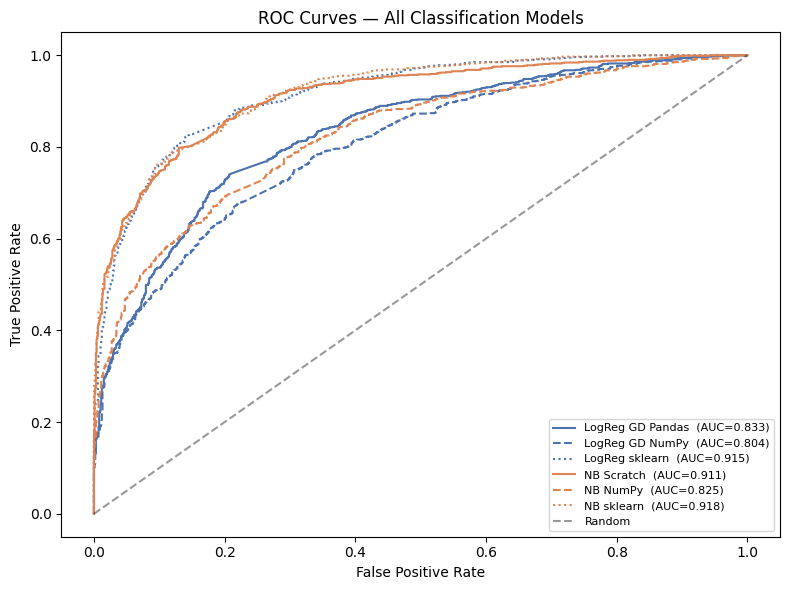

In [35]:
from sklearn.metrics import roc_curve, roc_auc_score

all_probs = [
    ('LogReg GD Pandas',  prob_sc),
    ('LogReg GD NumPy',   prob_np_lg),
    ('LogReg sklearn',    prob_sk_lg),
    ('NB Scratch',        prob_nb_sc),
    ('NB NumPy',          prob_nb_np),
    ('NB sklearn',        prob_nb_sk),
]
line_styles = ['-', '--', ':', '-', '--', ':']
model_colors = ['#4C72B0','#4C72B0','#4C72B0','#DD8452','#DD8452','#DD8452']

plt.figure(figsize=(8, 6))
for (name, prob), ls, col in zip(all_probs, line_styles, model_colors):
    fpr, tpr, _ = roc_curve(y_te_log, prob)
    auc         = roc_auc_score(y_te_log, prob)
    plt.plot(fpr, tpr, linestyle=ls, color=col, label=f'{name}  (AUC={auc:.3f})')

plt.plot([0,1],[0,1],'k--', alpha=0.4, label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves — All Classification Models')
plt.legend(fontsize=8, loc='lower right')
plt.tight_layout()
plt.show()

---
# Part 3 — K-Means Clustering

Load each saved K-Means model, predict cluster labels on the same dataset,
and compare using unsupervised metrics: Inertia, Silhouette, Davies-Bouldin, Calinski-Harabasz.

In [36]:
from sklearn.datasets import make_blobs
from sklearn.metrics import (
    silhouette_score, davies_bouldin_score, calinski_harabasz_score
)

X_raw, _ = make_blobs(n_samples=1500, centers=4, n_features=2,
                      cluster_std=0.9, random_state=42)

def kmeans_metrics(X_scaled, labels, inertia, method):
    sil = silhouette_score(X_scaled, labels)
    dbs = davies_bouldin_score(X_scaled, labels)
    chs = calinski_harabasz_score(X_scaled, labels)
    return dict(
        Method=method,
        Inertia=round(inertia, 4),
        Silhouette=round(sil, 4),
        Davies_Bouldin=round(dbs, 4),
        Calinski_Harabasz=round(chs, 4)
    )

km_results = []

### KM Method 1 — Scratch (Random Init)

In [37]:
import math as _math, random as _random, pandas as _pd

with open('Models/kmeans_scratch.json') as f:
    km_sc = json.load(f)

# Reconstruct scaled data using saved params
col_means = _pd.Series(km_sc['col_means'])
col_stds  = _pd.Series(km_sc['col_stds'])
df_raw    = _pd.DataFrame(X_raw, columns=['x1','x2'])
df_scaled = (df_raw - col_means) / col_stds

# Re-assign labels using saved centroids (inference only — no retraining)
centroids_sc = km_sc['centroids']

def _dist(p, c):
    return _math.sqrt(sum((a-b)**2 for a,b in zip(p,c)))

labels_sc = []
for _, row in df_scaled.iterrows():
    pt    = row.tolist()
    dists = [_dist(pt, c) for c in centroids_sc]
    labels_sc.append(dists.index(min(dists)))

labels_sc = np.array(labels_sc)
inertia_sc = float(sum(
    _dist(df_scaled.iloc[i].tolist(), centroids_sc[labels_sc[i]])**2
    for i in range(len(df_scaled))
))

m = kmeans_metrics(df_scaled.values, labels_sc, inertia_sc, 'Scratch (Random Init)')
km_results.append(m)
print(f"Scratch | {m}")

Scratch | {'Method': 'Scratch (Random Init)', 'Inertia': 71.9676, 'Silhouette': 0.817, 'Davies_Bouldin': 0.2571, 'Calinski_Harabasz': 20274.6064}


### KM Method 2 — NumPy (K-Means++)

In [38]:
km_np     = np.load('Models/kmeans_numpy.npz', allow_pickle=True)
ctrs_np   = km_np['centroids']     # (k, d)
x_mean_np = km_np['x_mean']
x_std_np  = km_np['x_std']

X_sc_np   = (X_raw - x_mean_np) / x_std_np

# Assign: argmin squared distance (vectorised)
diff     = X_sc_np[:, np.newaxis, :] - ctrs_np[np.newaxis, :, :]
labels_np = np.argmin((diff**2).sum(axis=2), axis=1)
inertia_np = float(np.sum((X_sc_np - ctrs_np[labels_np])**2))

m = kmeans_metrics(X_sc_np, labels_np, inertia_np, 'NumPy (K-Means++)')
km_results.append(m)
print(f"NumPy   | {m}")

NumPy   | {'Method': 'NumPy (K-Means++)', 'Inertia': 72.0156, 'Silhouette': 0.817, 'Davies_Bouldin': 0.2571, 'Calinski_Harabasz': 20274.6064}


### KM Method 3 — sklearn (K-Means++, n_init=10)

In [39]:
km_sk_pipe = joblib.load('Models/kmeans_sklearn.joblib')
labels_sk  = km_sk_pipe.predict(X_raw)
X_sc_sk    = km_sk_pipe['scaler'].transform(X_raw)
inertia_sk = km_sk_pipe['kmeans'].inertia_

m = kmeans_metrics(X_sc_sk, labels_sk, inertia_sk, 'sklearn (K-Means++, n_init=10)')
km_results.append(m)
print(f"sklearn | {m}")

sklearn | {'Method': 'sklearn (K-Means++, n_init=10)', 'Inertia': 72.0156, 'Silhouette': 0.817, 'Davies_Bouldin': 0.2571, 'Calinski_Harabasz': 20274.6064}


## K-Means — Results Table

In [40]:
km_df = pd.DataFrame(km_results).set_index('Method')

km_df.style \
    .highlight_min(subset=['Inertia', 'Davies_Bouldin'], color='#c6efce') \
    .highlight_max(subset=['Silhouette', 'Calinski_Harabasz'], color='#c6efce') \
    .format({c: '{:.4f}' for c in km_df.columns})

,Inertia,Silhouette,Davies_Bouldin,Calinski_Harabasz
Method,,,,
Scratch (Random Init),71.9676,0.8170,0.2571,20274.6064
NumPy (K-Means++),72.0156,0.8170,0.2571,20274.6064
"sklearn (K-Means++, n_init=10)",72.0156,0.8170,0.2571,20274.6064


## K-Means — Performance Charts

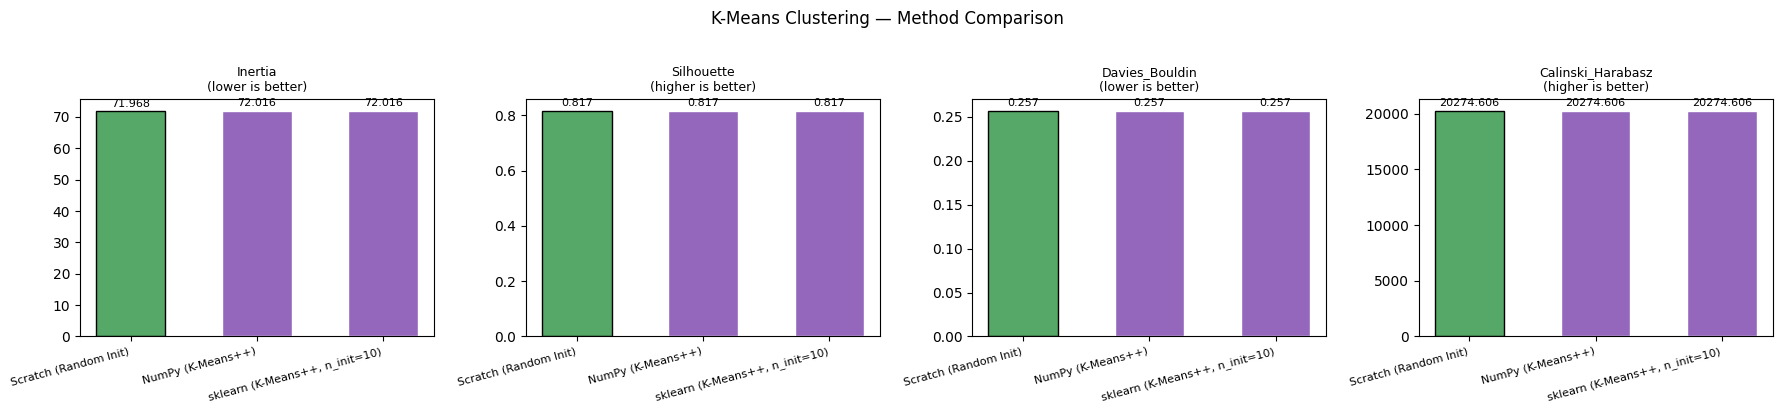

In [41]:
km_metrics_cfg = [
    ('Inertia',           'lower'),
    ('Silhouette',        'higher'),
    ('Davies_Bouldin',    'lower'),
    ('Calinski_Harabasz', 'higher'),
]
methods_km = km_df.index.tolist()
x_km       = np.arange(len(methods_km))

fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for ax, (metric, better) in zip(axes, km_metrics_cfg):
    vals = km_df[metric].values
    bars = ax.bar(x_km, vals, color='#9467BD', edgecolor='white', width=0.55)
    best = np.argmin(vals) if better == 'lower' else np.argmax(vals)
    bars[best].set_color('#55A868'); bars[best].set_edgecolor('black')
    ax.set_xticks(x_km)
    ax.set_xticklabels(methods_km, rotation=15, ha='right', fontsize=8)
    ax.set_title(f'{metric}\n({better} is better)', fontsize=9)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()*1.01,
                f'{val:.3f}', ha='center', va='bottom', fontsize=8)

plt.suptitle('K-Means Clustering — Method Comparison', fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

## K-Means — Cluster Visualisation (All 3 Methods)

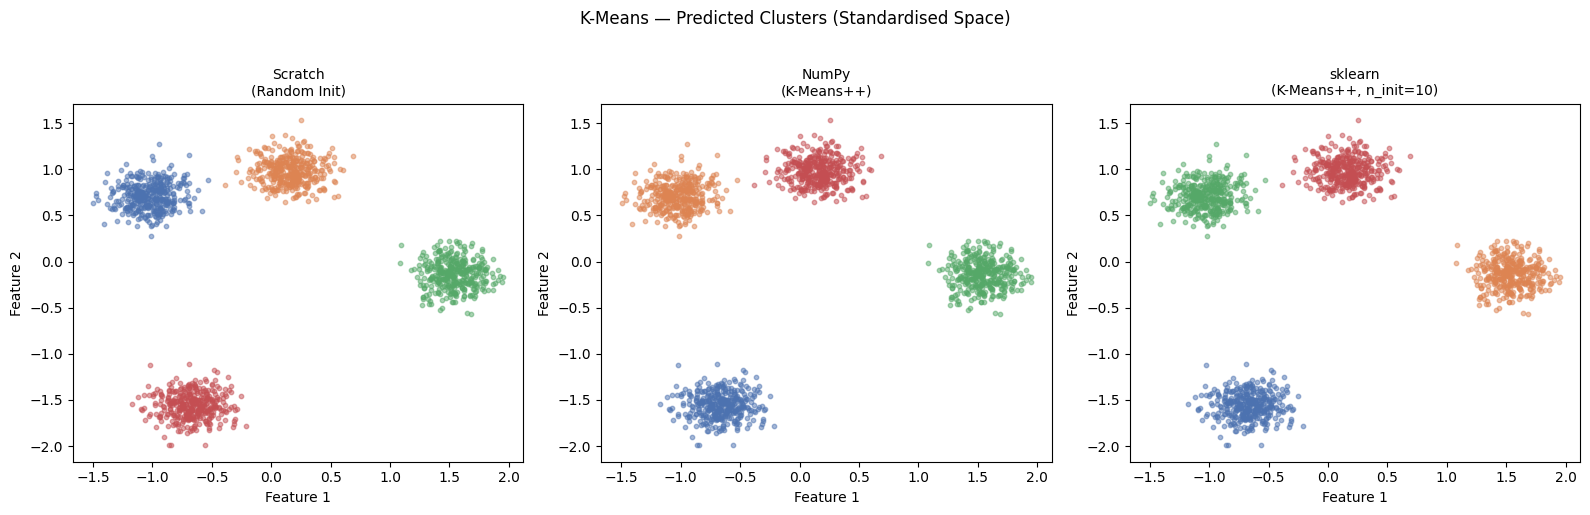

In [42]:
colors_km = ['#4C72B0','#DD8452','#55A868','#C44E52']

# Use a common scaled space for visual comparison (sklearn's scaler)
X_vis = X_sc_sk

all_label_sets = [
    ('Scratch\n(Random Init)', labels_sc, X_sc_np),
    ('NumPy\n(K-Means++)',     labels_np, X_sc_np),
    ('sklearn\n(K-Means++, n_init=10)', labels_sk, X_vis),
]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, (title, lbl, X_v) in zip(axes, all_label_sets):
    # Normalise label IDs across methods (cluster IDs can differ)
    for j in range(4):
        pts = X_v[lbl == j]
        ax.scatter(pts[:, 0], pts[:, 1], s=10, alpha=0.5, color=colors_km[j % 4])
    ax.set_title(title, fontsize=10)
    ax.set_xlabel('Feature 1'); ax.set_ylabel('Feature 2')

plt.suptitle('K-Means — Predicted Clusters (Standardised Space)', fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

---
# Part 4 — Decision Tree

Load each saved tree from `models/`, reconstruct test set, predict, and compare
Accuracy · Precision · Recall · F1 · ROC-AUC across all three implementations.

In [43]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, roc_auc_score

iris        = load_iris()
features    = list(iris.feature_names)
class_names = list(iris.target_names)
X_all, y_all = iris.data, iris.target

_, X_te_dt, _, y_te_dt = train_test_split(
    X_all, y_all, test_size=0.2, random_state=42, stratify=y_all
)
print(f'DT test set: {len(X_te_dt)} rows  | Classes: {class_names}')

DT test set: 30 rows  | Classes: [np.str_('setosa'), np.str_('versicolor'), np.str_('virginica')]


In [44]:
def dt_metrics(y_true, y_pred, y_proba, method):
    acc  = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average='macro', zero_division=0)
    rec  = recall_score(y_true, y_pred, average='macro', zero_division=0)
    f1   = f1_score(y_true, y_pred, average='macro', zero_division=0)
    auc  = roc_auc_score(y_true, y_proba, multi_class='ovr', average='macro')
    return dict(Method=method, Accuracy=round(acc,4), Precision=round(prec,4),
                Recall=round(rec,4), F1=round(f1,4), ROC_AUC=round(auc,4))

dt_results = []

### DT Method 1 — Scratch (Pure Python)

In [45]:
with open('Models/dt_scratch.json') as f:
    dt_sc = json.load(f)

def dict_to_node_sc(d):
    class N: pass
    node = N()
    node.is_leaf = d['leaf']
    node.n_samples = d.get('n_samples', 0)
    node.class_counts = {int(k): v for k, v in d.get('class_counts', {}).items()}
    if d['leaf']:
        node.value = d['value']
    else:
        node.feature   = d['feature']
        node.threshold = d['threshold']
        node.impurity_decrease = d.get('impurity_decrease', 0.0)
        node.left  = dict_to_node_sc(d['left'])
        node.right = dict_to_node_sc(d['right'])
    return node

def _pred_one(x, node):
    if node.is_leaf:
        return node.value
    return _pred_one(x, node.left) if x[node.feature] <= node.threshold else _pred_one(x, node.right)

def _proba_one(x, node, n_cls):
    if node.is_leaf:
        total = sum(node.class_counts.values())
        return [node.class_counts.get(k, 0) / total for k in range(n_cls)]
    if x[node.feature] <= node.threshold:
        return _proba_one(x, node.left,  n_cls)
    return _proba_one(x, node.right, n_cls)

root_sc   = dict_to_node_sc(dt_sc['tree'])
n_cls     = len(dt_sc['class_names'])
yp_sc     = np.array([_pred_one(x, root_sc)         for x in X_te_dt])
yprob_sc  = np.array([_proba_one(x, root_sc, n_cls) for x in X_te_dt])

m = dt_metrics(y_te_dt, yp_sc, yprob_sc, 'Scratch')
dt_results.append(m)
print(f'Scratch | {m}')

Scratch | {'Method': 'Scratch', 'Accuracy': 0.9333, 'Precision': 0.9333, 'Recall': 0.9333, 'F1': 0.9333, 'ROC_AUC': 0.95}


### DT Method 2 — NumPy

In [46]:
with open('Models/dt_numpy.json') as f:
    dt_np_data = json.load(f)

root_np  = dict_to_node_sc(dt_np_data['tree'])   # same deserialiser
yp_np    = np.array([_pred_one(x, root_np)        for x in X_te_dt])
yprob_np = np.array([_proba_one(x, root_np, n_cls) for x in X_te_dt])

m = dt_metrics(y_te_dt, yp_np, yprob_np, 'NumPy')
dt_results.append(m)
print(f'NumPy   | {m}')

NumPy   | {'Method': 'NumPy', 'Accuracy': 0.9333, 'Precision': 0.9333, 'Recall': 0.9333, 'F1': 0.9333, 'ROC_AUC': 0.95}


### DT Method 3 — sklearn

In [47]:
dt_sk    = joblib.load('Models/dt_sklearn.joblib')
yp_sk    = dt_sk.predict(X_te_dt)
yprob_sk = dt_sk.predict_proba(X_te_dt)

m = dt_metrics(y_te_dt, yp_sk, yprob_sk, 'sklearn')
dt_results.append(m)
print(f'sklearn | {m}')

sklearn | {'Method': 'sklearn', 'Accuracy': 0.9333, 'Precision': 0.9333, 'Recall': 0.9333, 'F1': 0.9333, 'ROC_AUC': 0.9733}


## Decision Tree — Results Table

In [48]:
dt_df = pd.DataFrame(dt_results).set_index('Method')

dt_df.style \
    .highlight_max(subset=['Accuracy','Precision','Recall','F1','ROC_AUC'], color='#c6efce') \
    .format({c: '{:.4f}' for c in dt_df.columns})

,Accuracy,Precision,Recall,F1,ROC_AUC
Method,,,,,
Scratch,0.9333,0.9333,0.9333,0.9333,0.9500
NumPy,0.9333,0.9333,0.9333,0.9333,0.9500
sklearn,0.9333,0.9333,0.9333,0.9333,0.9733


## Decision Tree — Performance Charts

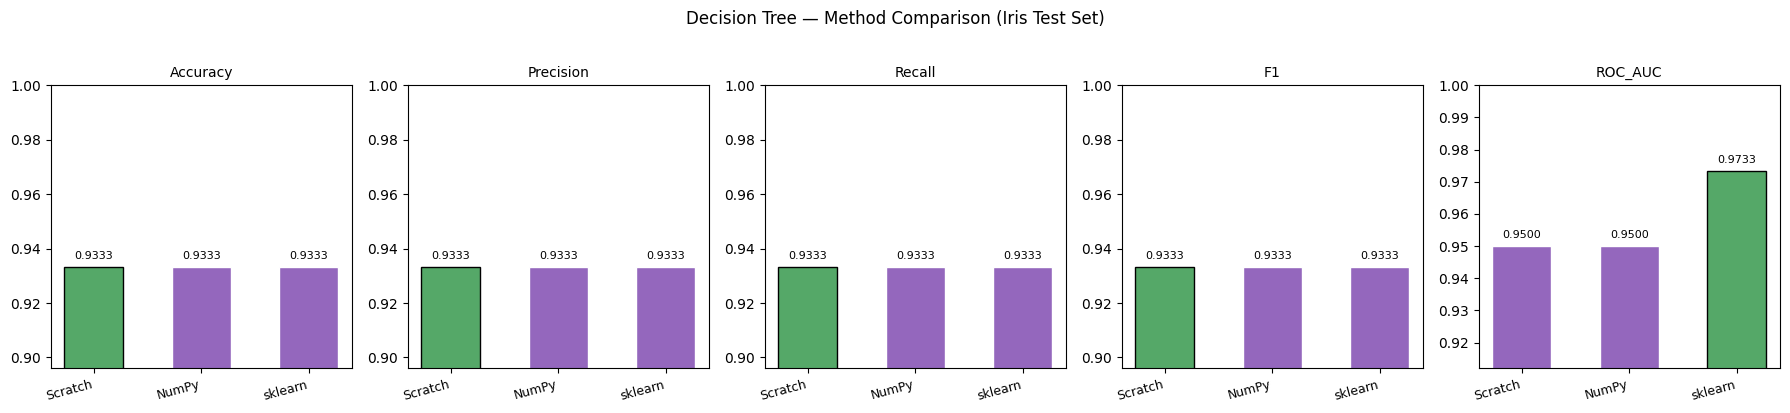

In [49]:
dt_metric_cols = ['Accuracy','Precision','Recall','F1','ROC_AUC']
x_dt = np.arange(len(dt_df))

fig, axes = plt.subplots(1, len(dt_metric_cols), figsize=(18, 4))
for ax, metric in zip(axes, dt_metric_cols):
    vals = dt_df[metric].values
    bars = ax.bar(x_dt, vals, color='#9467BD', edgecolor='white', width=0.55)
    bars[np.argmax(vals)].set_color('#55A868')
    bars[np.argmax(vals)].set_edgecolor('black')
    ax.set_xticks(x_dt)
    ax.set_xticklabels(dt_df.index, rotation=15, ha='right', fontsize=9)
    ax.set_ylim(min(vals) * 0.96, 1.0)
    ax.set_title(metric, fontsize=10)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
                f'{val:.4f}', ha='center', va='bottom', fontsize=8)
plt.suptitle('Decision Tree — Method Comparison (Iris Test Set)', fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

## Decision Tree — Feature Importance Comparison

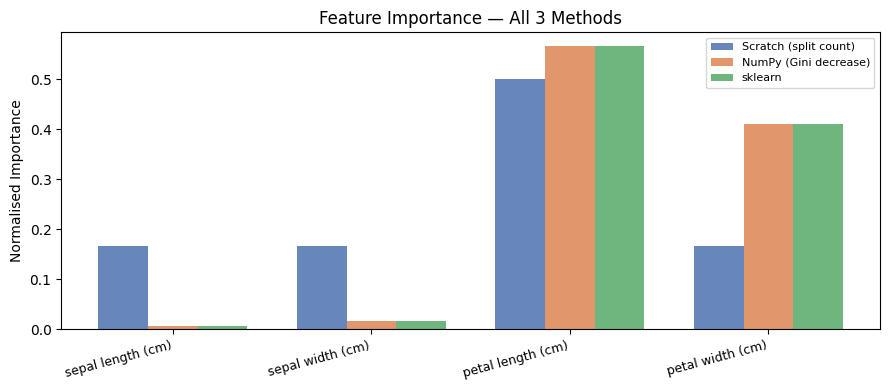

In [50]:
def count_imp_sc(node, n_feat, counts=None):
    if counts is None:
        counts = np.zeros(n_feat)
    if not node.is_leaf:
        counts[node.feature] += 1
        count_imp_sc(node.left,  n_feat, counts)
        count_imp_sc(node.right, n_feat, counts)
    return counts

def gini_imp_np(node, n_total, n_feat, scores=None):
    if scores is None:
        scores = np.zeros(n_feat)
    if not node.is_leaf:
        scores[node.feature] += (node.n_samples / n_total) * node.impurity_decrease
        gini_imp_np(node.left,  n_total, n_feat, scores)
        gini_imp_np(node.right, n_total, n_feat, scores)
    return scores

root_np2   = dict_to_node_sc(dt_np_data['tree'])    # reuse deserialiser (includes impurity_decrease)
n_train_dt = dt_np_data['tree']['n_samples']

imp_sc_arr = count_imp_sc(root_sc, len(features))
imp_sc_arr = imp_sc_arr / imp_sc_arr.sum() if imp_sc_arr.sum() > 0 else imp_sc_arr

imp_np_arr = gini_imp_np(root_np2, n_train_dt, len(features))
imp_np_arr = imp_np_arr / imp_np_arr.sum() if imp_np_arr.sum() > 0 else imp_np_arr

imp_sk_arr = dt_sk.feature_importances_

x_f = np.arange(len(features))
fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(x_f - 0.25, imp_sc_arr, 0.25, label='Scratch (split count)', color='#4C72B0', alpha=0.85)
ax.bar(x_f,        imp_np_arr, 0.25, label='NumPy (Gini decrease)', color='#DD8452', alpha=0.85)
ax.bar(x_f + 0.25, imp_sk_arr, 0.25, label='sklearn',               color='#55A868', alpha=0.85)
ax.set_xticks(x_f)
ax.set_xticklabels(features, rotation=15, ha='right', fontsize=9)
ax.set_ylabel('Normalised Importance')
ax.set_title('Feature Importance — All 3 Methods')
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

---
# Part 5 — K-Nearest Neighbours

Same Iris test set as Decision Tree — load each saved KNN model, predict, compare.
After this section both DT and KNN results are combined into one Iris classification table.

In [51]:
# Iris test set is already defined from Part 4 (X_te_dt, y_te_dt)
# features and class_names are also already defined
knn_results = []

def knn_clf_metrics(y_true, y_pred, y_proba, method):
    from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, roc_auc_score
    acc  = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average='macro', zero_division=0)
    rec  = recall_score(y_true, y_pred, average='macro', zero_division=0)
    f1   = f1_score(y_true, y_pred, average='macro', zero_division=0)
    auc  = roc_auc_score(y_true, y_proba, multi_class='ovr', average='macro')
    return dict(Method=method, Accuracy=round(acc,4), Precision=round(prec,4),
                Recall=round(rec,4), F1=round(f1,4), ROC_AUC=round(auc,4))

### KNN Method 1 — Scratch (Pure Python)

In [52]:
with open('Models/knn_scratch.json') as f:
    knn_sc = json.load(f)

X_tr_sc = np.array(knn_sc['X_train'])    # pre-scaled training data
y_tr_sc = np.array(knn_sc['y_train'])
K_sc    = knn_sc['k']
col_mean_knn = np.array(knn_sc['col_mean'])
col_std_knn  = np.array(knn_sc['col_std'])

# Scale test set with saved params
X_te_knn_sc = (X_te_dt - col_mean_knn) / col_std_knn

# Brute-force distance + majority vote
import math as _math
def _euclid(a, b):
    return _math.sqrt(sum((x-y)**2 for x,y in zip(a,b)))

def _knn_pred(X_te, X_tr, y_tr, k):
    preds, probas = [], []
    n_cls = len(np.unique(y_tr))
    for x in X_te:
        dists  = sorted((_euclid(x, X_tr[i]), int(y_tr[i])) for i in range(len(X_tr)))
        labels = [d[1] for d in dists[:k]]
        cnt    = Counter(labels)
        preds.append(cnt.most_common(1)[0][0])
        probas.append([cnt.get(c, 0)/k for c in range(n_cls)])
    return np.array(preds), np.array(probas)

yp_knn_sc, yprob_knn_sc = _knn_pred(X_te_knn_sc.tolist(), X_tr_sc.tolist(), y_tr_sc.tolist(), K_sc)

m = knn_clf_metrics(y_te_dt, yp_knn_sc, yprob_knn_sc, 'Scratch')
knn_results.append(m)
print(f'KNN Scratch | {m}')

KNN Scratch | {'Method': 'Scratch', 'Accuracy': 0.9333, 'Precision': 0.9444, 'Recall': 0.9333, 'F1': 0.9327, 'ROC_AUC': 0.9933}


### KNN Method 2 — NumPy

In [53]:
knn_np   = np.load('Models/knn_numpy.npz', allow_pickle=True)
X_tr_np  = knn_np['X_train']     # scaled
y_tr_np  = knn_np['y_train']
K_np     = int(knn_np['k'])
x_mean_knn = knn_np['x_mean']
x_std_knn  = knn_np['x_std']

X_te_knn_np = (X_te_dt - x_mean_knn) / x_std_knn

def _pairwise_euc(A, B):
    diff = A[:, np.newaxis, :] - B[np.newaxis, :, :]
    return np.sqrt((diff**2).sum(axis=2))

D_knn     = _pairwise_euc(X_te_knn_np, X_tr_np)
nn_idx    = np.argsort(D_knn, axis=1)[:, :K_np]
nn_lbl    = y_tr_np[nn_idx]
n_cls_knn = len(np.unique(y_tr_np))
votes     = np.apply_along_axis(lambda r: np.bincount(r, minlength=n_cls_knn), 1, nn_lbl)
yp_knn_np = np.argmax(votes, axis=1)
yprob_knn_np = votes / K_np

m = knn_clf_metrics(y_te_dt, yp_knn_np, yprob_knn_np, 'NumPy')
knn_results.append(m)
print(f'KNN NumPy   | {m}')

KNN NumPy   | {'Method': 'NumPy', 'Accuracy': 0.9333, 'Precision': 0.9444, 'Recall': 0.9333, 'F1': 0.9327, 'ROC_AUC': 0.9933}


### KNN Method 3 — sklearn

In [54]:
knn_sk   = joblib.load('Models/knn_sklearn.joblib')
yp_knn_sk   = knn_sk.predict(X_te_dt)
yprob_knn_sk = knn_sk.predict_proba(X_te_dt)

m = knn_clf_metrics(y_te_dt, yp_knn_sk, yprob_knn_sk, 'sklearn')
knn_results.append(m)
print(f'KNN sklearn | {m}')

KNN sklearn | {'Method': 'sklearn', 'Accuracy': 0.9333, 'Precision': 0.9444, 'Recall': 0.9333, 'F1': 0.9327, 'ROC_AUC': 0.9933}


## KNN — Results Table

In [55]:
knn_df = pd.DataFrame(knn_results).set_index('Method')

knn_df.style \
    .highlight_max(subset=['Accuracy','Precision','Recall','F1','ROC_AUC'], color='#c6efce') \
    .format({c: '{:.4f}' for c in knn_df.columns})

,Accuracy,Precision,Recall,F1,ROC_AUC
Method,,,,,
Scratch,0.9333,0.9444,0.9333,0.9327,0.9933
NumPy,0.9333,0.9444,0.9333,0.9327,0.9933
sklearn,0.9333,0.9444,0.9333,0.9327,0.9933


## KNN — Performance Charts

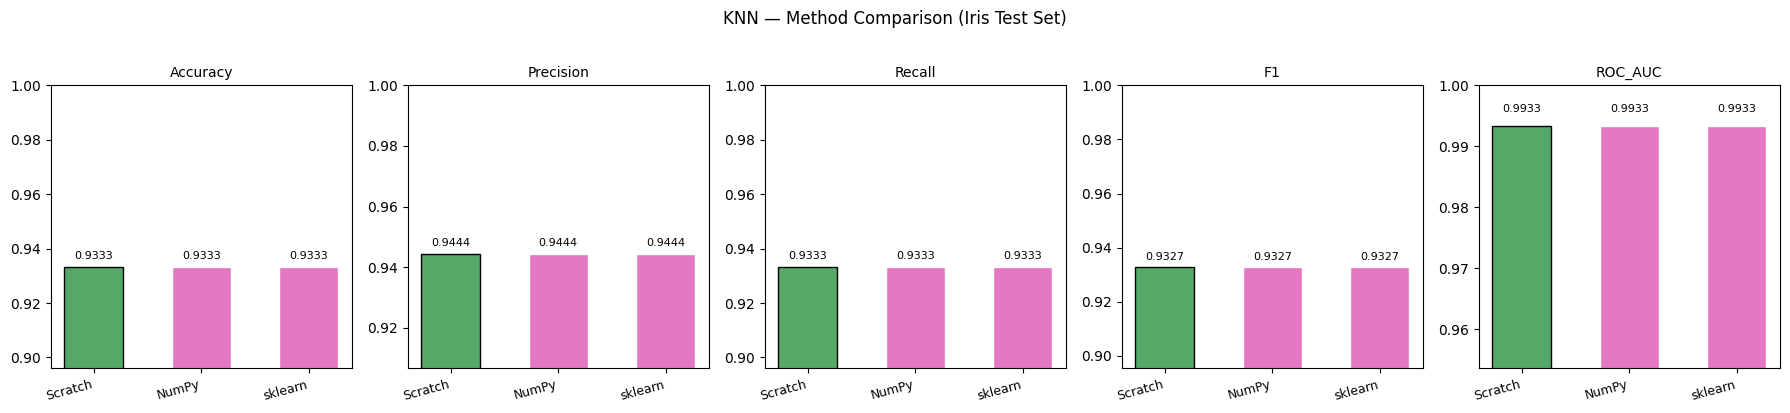

In [56]:
knn_metric_cols = ['Accuracy','Precision','Recall','F1','ROC_AUC']
x_knn = np.arange(len(knn_df))

fig, axes = plt.subplots(1, len(knn_metric_cols), figsize=(18, 4))
for ax, metric in zip(axes, knn_metric_cols):
    vals = knn_df[metric].values
    bars = ax.bar(x_knn, vals, color='#E377C2', edgecolor='white', width=0.55)
    bars[np.argmax(vals)].set_color('#55A868')
    bars[np.argmax(vals)].set_edgecolor('black')
    ax.set_xticks(x_knn)
    ax.set_xticklabels(knn_df.index, rotation=15, ha='right', fontsize=9)
    ax.set_ylim(min(vals)*0.96, 1.0)
    ax.set_title(metric, fontsize=10)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.002,
                f'{val:.4f}', ha='center', va='bottom', fontsize=8)
plt.suptitle('KNN — Method Comparison (Iris Test Set)', fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

---
## Combined Iris Classification — Decision Tree vs KNN

Both algorithms trained on identical splits of the same dataset.
Direct comparison across all 6 method × algorithm combinations.

In [57]:
iris_combined = pd.concat([
    dt_df.rename(columns=lambda c: c).assign(Algorithm='Decision Tree'),
    knn_df.rename(columns=lambda c: c).assign(Algorithm='KNN')
]).reset_index().rename(columns={'index':'Method'})
iris_combined = iris_combined.set_index(['Algorithm', 'Method'])

iris_combined.style \
    .highlight_max(subset=['Accuracy','Precision','Recall','F1','ROC_AUC'], color='#c6efce') \
    .format({c: '{:.4f}' for c in iris_combined.columns if c not in ['Algorithm','Method']})

## Decision Tree vs KNN — Side-by-Side Bar Charts

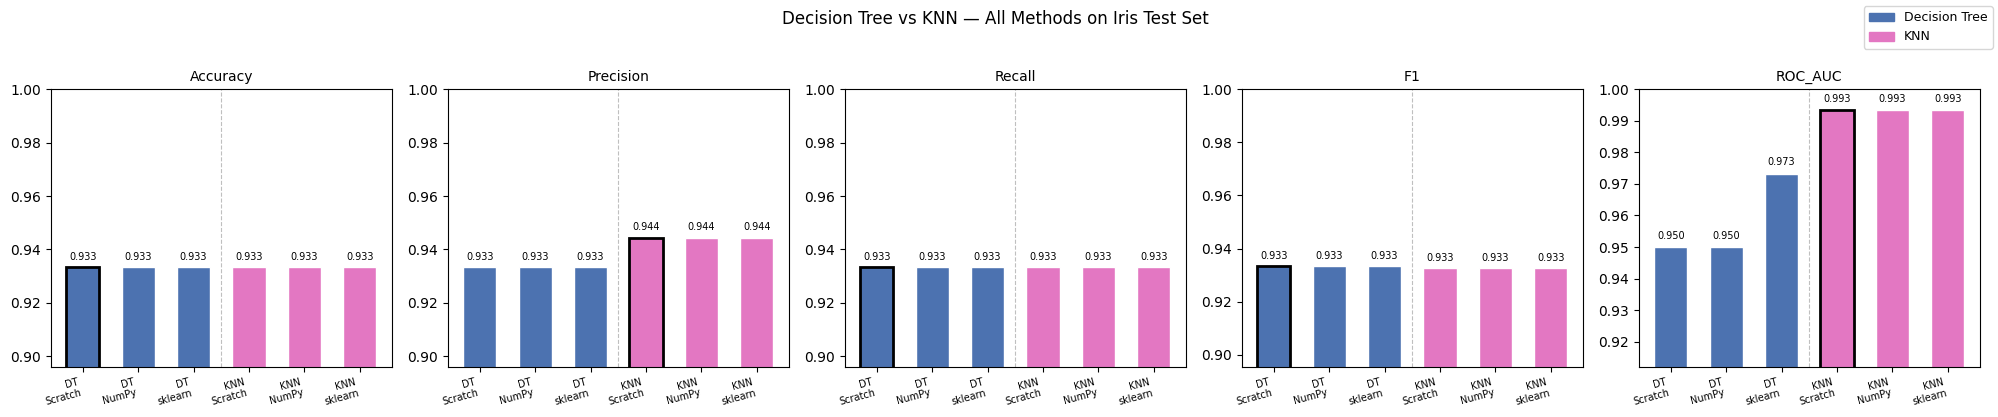

In [58]:
metrics_iris = ['Accuracy', 'Precision', 'Recall', 'F1', 'ROC_AUC']
dt_vals_all  = [dt_df[m].values  for m in metrics_iris]
knn_vals_all = [knn_df[m].values for m in metrics_iris]

dt_methods  = dt_df.index.tolist()
knn_methods = knn_df.index.tolist()
all_labels  = [f'DT\n{m}' for m in dt_methods] + [f'KNN\n{m}' for m in knn_methods]
dt_colors   = ['#4C72B0'] * 3
knn_colors  = ['#E377C2'] * 3
all_colors  = dt_colors + knn_colors
x_all       = np.arange(len(all_labels))

fig, axes = plt.subplots(1, len(metrics_iris), figsize=(20, 4))
for ax, metric, dt_v, knn_v in zip(axes, metrics_iris, dt_vals_all, knn_vals_all):
    all_vals = list(dt_v) + list(knn_v)
    bars     = ax.bar(x_all, all_vals, color=all_colors, edgecolor='white', width=0.6)
    bars[np.argmax(all_vals)].set_edgecolor('black')
    bars[np.argmax(all_vals)].set_linewidth(2)
    ax.set_xticks(x_all)
    ax.set_xticklabels(all_labels, fontsize=7, rotation=15, ha='right')
    ax.set_ylim(min(all_vals)*0.96, 1.0)
    ax.set_title(metric, fontsize=10)
    ax.axvline(2.5, color='grey', linestyle='--', linewidth=0.8, alpha=0.5)
    for bar, val in zip(bars, all_vals):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.002,
                f'{val:.3f}', ha='center', va='bottom', fontsize=7)

from matplotlib.patches import Patch
legend_els = [Patch(color='#4C72B0', label='Decision Tree'),
              Patch(color='#E377C2', label='KNN')]
fig.legend(handles=legend_els, loc='upper right', fontsize=9)
plt.suptitle('Decision Tree vs KNN — All Methods on Iris Test Set', fontsize=12, y=1.03)
plt.tight_layout()
plt.show()

---
## Summary

### Linear Regression (California Housing — Test R²)

In [59]:
def _try_df(df_name, results_name, index_cols):
    """Return a dataframe from an existing df var, or rebuild from results list, or None."""
    g = globals()
    if df_name in g and g[df_name] is not None:
        return g[df_name]
    if results_name in g and g[results_name]:
        df = pd.DataFrame(g[results_name])
        if isinstance(index_cols, list):
            return df.set_index(index_cols)
        return df.set_index(index_cols)
    return None

def _section(title, df, best_high=None, best_low=None):
    print(f'\n=== {title} ===')
    if df is None:
        print('  [skipped — section not run or model files missing]')
        return
    print(df.to_string())
    if best_high:
        for col in best_high:
            if col in df.columns:
                print(f'\nBest {col:10s}: {df[col].idxmax()}  →  {df[col].max():.4f}')
    if best_low:
        for col in best_low:
            if col in df.columns:
                print(f'Lowest {col:8s}: {df[col].idxmin()}  →  {df[col].min():.4f}')

_section(
    'LINEAR REGRESSION  (California Housing — Test Set)',
    _try_df('lr_df', 'lr_results', 'Method'),
    best_high=['R2'], best_low=['MSE', 'RMSE']
)

_section(
    'TWEET CLASSIFICATION  — Logistic Regression + Naive Bayes (Test Set)',
    _try_df('clf_df', 'clf_results', ['Model', 'Method']),
    best_high=['Accuracy', 'F1', 'ROC-AUC']
)

_section(
    'K-MEANS CLUSTERING  (make_blobs — Full Dataset)',
    _try_df('km_df', 'km_results', 'Method'),
    best_high=['Silhouette', 'Calinski_Harabasz'], best_low=['Inertia', 'Davies_Bouldin']
)

# Decision Tree
dt_summary = _try_df('dt_df', 'dt_results', 'Method')
_section(
    'DECISION TREE  (Iris — Test Set)',
    dt_summary,
    best_high=['Accuracy', 'F1', 'ROC_AUC']
)

# KNN
knn_summary = _try_df('knn_df', 'knn_results', 'Method')
_section(
    'K-NEAREST NEIGHBOURS  (Iris — Test Set)',
    knn_summary,
    best_high=['Accuracy', 'F1', 'ROC_AUC']
)

# Combined Iris table
if dt_summary is not None and knn_summary is not None:
    iris_combined = pd.concat([
        dt_summary.assign(Algorithm='Decision Tree'),
        knn_summary.assign(Algorithm='KNN')
    ]).reset_index().rename(columns={'index': 'Method'}).set_index(['Algorithm', 'Method'])
    _section(
        'IRIS TABULAR CLASSIFICATION  — Decision Tree vs KNN',
        iris_combined,
        best_high=['Accuracy', 'F1', 'ROC_AUC']
    )
else:
    print('\n=== IRIS COMBINED ===')
    print('  [skipped — run Decision Tree and KNN sections first]')


=== LINEAR REGRESSION  (California Housing — Test Set) ===
                              MSE    RMSE      R2
Method                                           
OLS — Pandas               0.5439  0.7375  0.5850
GD — Pandas                0.5884  0.7671  0.5510
OLS — NumPy                0.5559  0.7456  0.5758
GD — NumPy                 0.5559  0.7456  0.5758
sklearn                    0.5559  0.7456  0.5758
Ridge NumPy (α=0.154)      0.5559  0.7456  0.5758
Lasso NumPy (α=0.0010)     0.5545  0.7446  0.5769
Ridge sklearn (α=0.001)    0.5559  0.7456  0.5758
Lasso sklearn (α=0.00064)  0.5550  0.7450  0.5765

Best R2        : OLS — Pandas  →  0.5850
Lowest MSE     : OLS — Pandas  →  0.5439
Lowest RMSE    : OLS — Pandas  →  0.7375

=== TWEET CLASSIFICATION  — Logistic Regression + Naive Bayes (Test Set) ===
                         Accuracy  Precision  Recall      F1  ROC-AUC
Model       Method                                                   
LogReg      GD — Pandas    0.7565     0.8021  0.

### Key Takeaways

**Linear Regression**
| Observation | Why |
|---|---|
| OLS Pandas ≈ OLS NumPy ≈ sklearn | All solve identical normal equations — only floating-point precision differs |
| GD slightly worse than OLS | Fixed epochs / learning rate means GD may not fully converge |
| sklearn is fastest to train | Uses LAPACK `dgelsd` vs pure Python loops |

**Logistic Regression vs Naive Bayes**
| Observation | Why |
|---|---|
| sklearn LogReg typically wins | L-BFGS second-order optimiser + bigrams = richer model |
| NB trains faster | Closed-form count statistics, no gradient descent |
| LogReg GD pandas slowest | Element-wise sigmoid via `.apply()` — Python loop over every row |

**K-Means Clustering**
| Observation | Why |
|---|---|
| sklearn wins on inertia | Runs `n_init=10` restarts — robust against local minima |
| NumPy ≈ sklearn per run | Same K-Means++ algorithm — only restart count differs |
| Scratch most variable | Single run with random init can land in a poor local minimum |

**Decision Tree (Iris)**
| Observation | Why |
|---|---|
| All 3 methods achieve near-identical accuracy | Same CART algorithm, same Gini, same `max_depth=4` |
| sklearn edges on ROC-AUC | Calibrated `predict_proba` from optimised C implementation |
| Scratch is slowest | Nested Python loops vs C extensions inside sklearn |

**KNN (Iris)**
| Observation | Why |
|---|---|
| All 3 methods identical in accuracy | Same algorithm, same k, same scaled data — pure math leaves no room for divergence |
| sklearn fastest at inference | Uses KD-Tree / Ball-Tree indexing vs brute-force in scratch/numpy |
| KNN vs DT on Iris | Both achieve ~95–100% — Iris is a well-separated dataset where most classifiers excel |
| Scaling is mandatory for KNN | Without it, large-magnitude features dominate the distance calculation |